In [131]:
import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d



---


In [132]:
# action(1/1)：对MMDD设置要计算的日期
MMDD = '0701'

# 所有计算结果都在底部

---

In [133]:
df_opt = pd.read_csv(f'ifind_raw_data/{MMDD}_588000SH2607.csv')
df_opt = df_opt.dropna()

date = df_opt['date'][0]
multiplier = df_opt['mul'][0]
Spot = df_opt['ETF_close'][0]
DTE_n = df_opt['DTE_n'][0]
expiry_str = df_opt['last_date'][0]

N = norm.cdf
sqrt_2pi = np.sqrt(2 * np.pi)

In [134]:
def get_tau(DTE_n):
    tau = DTE_n / 360.0
    return tau

def get_shibor_rate_by_date(
        target_date_str, file_path="Shibor_Historical_Data.xlsx", tau = None):
    """
    读取Shibor历史数据表，根据查询日期获取对应的无风险利率。
    增加了对Date列类型的强制防御，防止Excel格式转换导致的识别失败。
    """

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到Shibor数据文件: {file_path}")

    # 1. 读取 Excel，跳过最后两行的附注
    df_shibor = pd.read_excel(file_path, skipfooter=2)

    # 强行统一转换为标准日期对象
    df_shibor["Date"] = pd.to_datetime(df_shibor["Date"])

    # 2. 统一查询日期的格式
    target_date = pd.to_datetime(target_date_str)

    # 3. 匹配日期行
    matched_row = df_shibor[df_shibor["Date"] == target_date]

    if not matched_row.empty:
        row_data = matched_row.iloc[0]
    else:
        # 如果没有匹配到，读取有效数据内容的第一行
        row_data = df_shibor.iloc[0]

        # 【修复点】确保 row_data["Date"] 绝对是 Timestamp 对象，然后再调用 strftime
        actual_date_obj = pd.to_datetime(row_data["Date"])
        print(f"⚠️ 警告：未找到日期 {target_date_str} 的 Shibor 数据，已默认启用最近期记录 (日期: {actual_date_obj.strftime('%Y-%m-%d')})")

    # 4. 提取各期限的利率数据并转换为纯小数
    shibor_days = np.array([1, 7, 14, 30, 90, 180, 270, 365])
    shibor_rates = np.array([
        row_data["O/N"],
        row_data["1W"],
        row_data["2W"],
        row_data["1M"],
        row_data["3M"],
        row_data["6M"],
        row_data["9M"],
        row_data["1Y"]
    ]) / 100.0

    if tau is None:
        return dict(zip(shibor_days, shibor_rates))

    # 5. 根据期权实际剩余天数进行动态线性插值
    opt_days = tau * 360
    r_interpolator = interp1d(
        shibor_days,
        shibor_rates,
        kind="linear",
        bounds_error=False,
        fill_value=(shibor_rates[0], shibor_rates[-1])
    )

    exact_r = float(r_interpolator(opt_days))
    return exact_r


In [135]:
def parse_single(name):
    """单独解析 1 个 name 字符串，返回 3 个值"""
    name = str(name)
    is_call = 1 if "购" in name else 0
    is_put = 1 if "沽" in name else 0
    numbers = re.findall(r"\d+", name)
    strike = float(numbers[-1]) / 1000 if numbers else np.nan
    return is_call, is_put, strike

def add_parsed_columns(df_opt):
    """给 df_opt 增加 3 列：is_call, is_put, strike_price"""
    df = df_opt.copy()
    parsed = df["name"].apply(parse_single)
    df[["is_call", "is_put", "strike_price"]] \
        = pd.DataFrame(parsed.tolist(), index=df.index)
    return df

In [136]:
def calculate_max_pain(df):
    strikes = sorted(df["strike_price"].dropna().unique())
    if not strikes:
        return np.nan
    pain_list = []
    calls = df[df["is_call"] == 1]
    puts = df[df["is_put"] == 1]
    for test_strike in strikes:
        call_pain = calls.apply(
            lambda x: x["oi"] * max(0, test_strike - x["strike_price"]),
            axis=1).sum()
        put_pain = puts.apply(
            lambda x: x["oi"] * max(0, x["strike_price"] - test_strike),
            axis=1).sum()
        pain_list.append((test_strike, call_pain + put_pain))
    return min(pain_list, key=lambda x: x[1])[0]

def calc_gamma_exposure(df_opt, spot_price, date):
    # 解析字段
    df_opt = add_parsed_columns(df_opt)
    df_target = df_opt[["is_call", "is_put",
                        "strike_price", "oi",
                        "gamma", 'iv', 'settle']].copy()



    # 压力墙 / 支撑墙
    call_wall = (df_target[
        df_target["is_call"] == 1].groupby("strike_price")["oi"]
                 .sum().idxmax())

    put_wall = (df_target[
        df_target["is_put"] == 1].groupby("strike_price")["oi"]
                .sum().idxmax())

    # 最大痛苦点
    max_pain = calculate_max_pain(df_target)

    # GEX 计算
    df_target["gex_sign"] = np.where(df_target["is_call"] == 1, 1, -1)
    df_target["gex_amount"] = (
        df_target["gamma"] * df_target["oi"] * multiplier
        * spot_price * spot_price * 0.01 * df_target["gex_sign"]
    )
    net_gex = df_target["gex_amount"].sum() / 1_000_000

    # 行权价汇总
    df_strike = df_target.groupby("strike_price", as_index=False)["gex_amount"].sum().sort_values("strike_price").reset_index(drop=True)


    gex_curve_df, zero_gamma, cs_call, cs_put = (
        compute_gex_curve_with_db_iv(df_target,
                                     Spot, multiplier,
                                     padding,
                                     tau, rf_dynamic,
                                     step=0.005))

    zero_gamma = df_target['strike_price'].max() \
        if zero_gamma is None else zero_gamma

    # ✅ 输出：1行DF 指标表
    metrics_df = pd.DataFrame([{
        'date': date,
        'spot': round(float(Spot), 3),
        "put_wall": round(float(put_wall), 3),
        "call_wall": round(float(call_wall), 3),
        "max_pain": round(float(max_pain), 3),
        "net_gex(M)": round(float(net_gex), 2),
        'zero-gamma': round(float(zero_gamma), 3),
    }])

    # 行权价GEX明细
    gex_detail_df = df_strike.copy()
    #检查iv曲线使用的临时df
    df_target_temp = df_target.copy()

    return metrics_df, gex_detail_df, gex_curve_df, cs_call, cs_put, df_target_temp

In [137]:
def find_valid_zero_gamma(df_curve, min_K, max_K, spot_price):
    df_in_K = df_curve[(df_curve["test_price"] >= min_K) &
                       (df_curve["test_price"] <= max_K)].copy()
    if len(df_in_K) < 2:
        return None

    df_in_K["prev_gex"] = df_in_K["total_gex"].shift(1)
    df_in_K["cross_zero"] = df_in_K["total_gex"] * df_in_K["prev_gex"] < 0
    zero_candidates = df_in_K[df_in_K["cross_zero"]].copy()

    if zero_candidates.empty:
        return None

    zero_candidates["dist_atm"] = abs(zero_candidates["test_price"] - spot_price)
    best_zero_pt = zero_candidates.loc[zero_candidates["dist_atm"].idxmin()]
    return round(best_zero_pt["test_price"], 3)

# -----------------------
# 主函数：直接利用数据库现成IV构建Smile并寻找Zero Gamma。
# -----------------------
def compute_gex_curve_with_db_iv(
        df_opt, spot_price, multiplier,
        padding, tau, r=0.015, step=0.001):

    df = df_opt.copy()
    S0 = spot_price

    # 阶段1：直接使用ifind隐含波动率
    # 分别为 Call 和 Put 建立独立的 Smile 曲线
    df_call = df[df["is_call"] == 1].sort_values("strike_price")
    df_put = df[df["is_call"] == 0].sort_values("strike_price")

    # 计算收盘时的 Moneyness (K/S0) 作为插值基准
    moneyness_call_base = df_call["strike_price"].values / S0
    iv_call_base = df_call["iv"].values

    moneyness_put_base = df_put["strike_price"].values / S0
    iv_put_base = df_put["iv"].values

    # 使用 CubicSpline 拟合以 Moneyness 为自变量的 Smile 曲线
    cs_call = CubicSpline(moneyness_call_base, iv_call_base, extrapolate=True)
    cs_put = CubicSpline(moneyness_put_base, iv_put_base, extrapolate=True)

    # 提取全局固定数组
    K_arr = df["strike_price"].values
    is_call_arr = df["is_call"].values
    oi_arr = df["oi"].values
    sqrt_tau = np.sqrt(tau)

    # 生成模拟现货细分价格区间
    min_K = K_arr.min()
    max_K = K_arr.max()
    min_sim_S = max(round(S0 * (1 - padding), 3), min_K)
    max_sim_S = min(round(S0 * (1 + padding), 3), max_K)
    sim_S_list = np.arange(min_sim_S, max_sim_S + step, step)
    sim_S_list = np.round(sim_S_list, 3)

    curve_result = []

    # 阶段2：遍历模拟现货 S，动态从 Smile 曲线中抽取新 IV，批量计算 Gamma
    for sim_S in sim_S_list:
        # 当现货价格变为 sim_S 时，各合约对应的“新 Moneyness”
        current_moneyness = K_arr / sim_S

        # 根据认购/认沽身份，动态从对应的 Smile 曲线中插值抽取 iv_dynamic
        iv_dynamic = np.where(
            is_call_arr == 1,
            cs_call(current_moneyness),
            cs_put(current_moneyness)
        )
        # 边界安全平滑：防止三次样条外推时出现极端异常值
        iv_dynamic = np.clip(iv_dynamic, 0.01, 5.0)

        # 标准 BS Gamma 正向公式，向量化批量计算所有合约
        ln_SK = np.log(sim_S / K_arr)
        d1 = (ln_SK + (r + 0.5 * iv_dynamic**2) * tau) / (iv_dynamic * sqrt_tau)
        pdf_d1 = np.exp(-d1**2 / 2) / sqrt_2pi
        gamma_single = pdf_d1 / (sim_S * iv_dynamic * sqrt_tau)

        # 做市商GEX符号区分（Call为负，Put为正）# gemini推荐
        # 目前仍然设置call+，put-
        sign_weight = np.where(is_call_arr == 1, 1, -1)
        single_gex = gamma_single * oi_arr * multiplier * (sim_S ** 2) * 0.01 * sign_weight
        agg_total_gex = single_gex.sum()

        curve_result.append({"test_price": sim_S, "total_gex": agg_total_gex})

    df_curve = pd.DataFrame(curve_result)

    # 阶段3：基于连续曲线寻找离 ATM 最近的 Zero Gamma 点
    zero_gamma_val = find_valid_zero_gamma(df_curve, min_K, max_K, spot_price)

    return df_curve, zero_gamma_val, cs_call, cs_put

In [138]:
def inspect_spline_fit(df_opt, spot_price, cs_call, cs_put):
    """
    打印检查 CubicSpline 的拟合效果，对比原始数据与插值数据
    """

    df_opt = add_parsed_columns(df_opt)

    print("="*20 + " 波动率微笑曲线 (Smile) 拟合检查 " + "="*20)

    # 1. 提取原始数据用于对比
    df_call = df_opt[df_opt["is_call"] == 1].copy()
    df_call["moneyness"] = df_call["strike_price"] / spot_price

    print("\n[1] 认购期权 (Call) 原始数据库 IV vs 样条插值 IV 采样检查:")
    print("-" * 65)
    print(f"{'行权价(K)':<10}{'Moneyness':<12}{'数据库原IV':<12}{'Spline插值IV':<15}{'残差(Error)':<10}")
    print("-" * 65)
    for _, row in df_call.sort_values("strike_price").iterrows():
        m = row["moneyness"]
        raw_iv = row["iv"]
        spline_iv = float(cs_call(m)) # 调用cs_call对象计算
        error = spline_iv - raw_iv
        print(f"{row['strike_price']:<12.3f}{m:<14.3f}{raw_iv:<14.4f}{spline_iv:<16.4f}{error:<10.4e}")

    # 2. 检查外推（Extrapolate）表现
    print("\n[2] 边界外推（Extrapolate）安全检查:")
    print("-" * 50)
    # 故意制造一些超出原始行权价范围的极端 Moneyness
    test_extrapolate = [0.70, 0.75, 1.25, 1.30]
    print(f"{'测试Moneyness':<15}{'Call外推IV':<15}{'Put外推IV':<15}")
    print("-" * 50)
    for m in test_extrapolate:
        iv_c = float(cs_call(m))
        iv_p = float(cs_put(m))
        print(f"{m:<17.2f}{iv_c:<17.4f}{iv_p:<17.4f}")
    print("="*60)

def plot_inspect_smile(df_opt, spot_price, cs_call, cs_put):
    """
    绘制 Smile 曲线拟合结果，直观检查插值与外推是否平滑
    """

    df_opt = add_parsed_columns(df_opt)

    # 1. 准备原始散点
    df_c = df_opt[df_opt["is_call"] == 1].sort_values("strike_price")
    df_p = df_opt[df_opt["is_call"] == 0].sort_values("strike_price")

    m_c_raw = df_c["strike_price"].values / spot_price
    iv_c_raw = df_c["iv"].values

    m_p_raw = df_p["strike_price"].values / spot_price
    iv_p_raw = df_p["iv"].values

    # 2. 生成高密度模拟 Moneyness 轴（向左右各多延伸 10% 用于观察外推表现）
    global_min_m = min(m_c_raw.min(), m_p_raw.min())
    global_max_m = max(m_c_raw.max(), m_p_raw.max())

    m_dense = np.linspace(global_min_m - 0.1, global_max_m + 0.1, 300)

    # 3. 计算插值线（带上限兜底，防止外推飞天）
    iv_c_dense = np.clip(cs_call(m_dense), 0.01, 5.0)
    iv_p_dense = np.clip(cs_put(m_dense), 0.01, 5.0)

    # 4. 开始绘图
    plt.figure(figsize=(12, 5))

    # --- 左图：Call 微笑曲线 ---
    plt.subplot(1, 2, 1)
    plt.scatter(m_c_raw, iv_c_raw, color='crimson', label='Raw DB IV (Call)', s=40, zorder=3)
    plt.plot(m_dense, iv_c_dense, color='royalblue', linestyle='--', linewidth=1.5, label='CubicSpline Curve')
    plt.axvline(1.0, color='darkgray', linestyle=':', label='ATM (M=1.0)')
    plt.title("Call Option Volatility Smile (Sticky Delta)", fontsize=11)
    plt.xlabel("Moneyness (K / S)")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- 右图：Put 微笑曲线 ---
    plt.subplot(1, 2, 2)
    plt.scatter(m_p_raw, iv_p_raw, color='darkorange', label='Raw DB IV (Put)', s=40, zorder=3)
    plt.plot(m_dense, iv_p_dense, color='forestgreen', linestyle='--', linewidth=1.5, label='CubicSpline Curve')
    plt.axvline(1.0, color='darkgray', linestyle=':', label='ATM (M=1.0)')
    plt.title("Put Option Volatility Smile (Sticky Delta)", fontsize=11)
    plt.xlabel("Moneyness (K / S)")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [139]:
def get_25delta_iv(df_tag):
    """
    从单标的单到期日期权链df_tag中获取25delta看涨、25delta看跌对应IV，并输出差值
    规则：
    1. is_call == 1 看涨，找delta最接近0.25的行权价，取出iv
    2. is_put == 1 看跌，找delta最接近-0.25的行权价，取出iv
    return: call_25iv, put_25iv, iv_spread
    """
    # 拆分看涨、看跌子集
    df_call = df_tag[df_tag["is_call"] == 1].copy()
    df_put = df_tag[df_tag["is_put"] == 1].copy()

    # 看涨：delta离0.25绝对值最小
    df_call["delta_diff_C25"] = abs(df_call["delta"] - 0.25)
    call_25_row = df_call.loc[df_call["delta_diff_C25"].idxmin()]
    call_25iv = call_25_row["iv"]
    call_strike = call_25_row["strike_price"]
    call_delta = call_25_row["delta"]

    # 看跌：delta离-0.25绝对值最小
    df_put["delta_diff_P25"] = abs(df_put["delta"] - (-0.25))
    put_25_row = df_put.loc[df_put["delta_diff_P25"].idxmin()]
    put_25iv = put_25_row["iv"]
    put_strike = put_25_row["strike_price"]
    put_delta = put_25_row["delta"]

    # 计算IV差值（看涨IV - 看跌IV）
    iv_vol_ratio = (call_25iv / put_25iv).round(4)
    iv_diff = call_25iv - put_25iv

    risk_reversal_price = put_strike - call_strike

    # 打印输出结果信息
    print("===== 25 Delta Skew =====")
    print(f"Call 25 Delta | Target delta=0.25, Actual delta={call_delta:.4f}, Strike={call_strike}, IV={call_25iv:.4f}")
    print(f"Put 25 Delta | Target delta=-0.25, Actual delta={put_delta:.4f}, Strike={put_strike}, IV={put_25iv:.4f}")
    print('')
    print(f"Price of the Risk Reversal (P25delta_prc - C25delta_prc) = {risk_reversal_price:.2f}")
    print(f"25Delta Skew (C25delta - P25delta) = {iv_diff:.4f}")
    print(f"Volatility Ration (C25delta / P25delta) = {iv_vol_ratio:.4f}")

    return call_25iv, put_25iv, iv_vol_ratio, iv_diff, risk_reversal_price

def get_atm_iv(df_tag, spot):
    """
    从单到期日期权链df_tag中找到行权价strike最贴近现货spot的合约，返回其iv(平值IV)
    参数：
        df_tag: DataFrame，包含strike、iv列的期权链数据
        spot: float，标的现货价格
    返回：
        atm_iv: float，平值合约波动率
        atm_strike: float，对应平值行权价
    """
    # 计算每个行权价与现货的价差绝对值
    df = df_tag.copy()
    df['strike_diff'] = abs(df['strike_price'] - spot)

    # 取差值最小的一行
    atm_row = df.loc[df['strike_diff'].idxmin()]

    atm_strike = atm_row['strike_price']
    atm_iv = atm_row['iv']*100

    print(f"Spot Price: {spot:.3f}")
    print(f"ATM Strike: {atm_strike:.3f}, ATM IV: {atm_iv:.3f}")

    return atm_iv, atm_strike

In [140]:
# ==============================================================================
# 通用坐标转换函数（全局共用，保证上下图竖线X位置完全对齐）
# ==============================================================================
def get_x_pos(price, strikes):
    if np.isnan(price):
        return None
    for i in range(len(strikes)-1):
        if strikes[i] <= price <= strikes[i+1]:
            return i + (price - strikes[i])/(strikes[i+1] - strikes[i])
    if price <= strikes[0]:
        return 0
    if price >= strikes[-1]:
        return len(strikes)-1
    return None

def plot_gamma_exposure(df_tag, gex_table, metrics_df):
    # ==============================================================================
    # 1) 第一张图：OI 持仓双柱图（完全保留你原有代码无修改）
    # ==============================================================================

    call_wall    = metrics_df['call_wall'].iloc[0]
    put_wall     = metrics_df['put_wall'].iloc[0]
    max_pain     = metrics_df['max_pain'].iloc[0]
    zero_gamma   = metrics_df['zero-gamma'].iloc[0]
    spot_price  = float(Spot)
    net_gex = metrics_df['net_gex(M)'].iloc[0]



    strikes = sorted(df_tag['strike_price'].unique())

    call_oi = [
        df_tag[(df_tag['strike_price'] == s) &
                      (df_tag['is_call'] == 1)]['oi'].sum() for s in strikes
                ]
    put_oi  = [
        df_tag[(df_tag['strike_price'] == s) &
                      (df_tag['is_put'] == 1)]['oi'].sum() for s in strikes
                ]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

    bar_width = 0.35
    index = np.arange(len(strikes))

    rects1 = ax1.bar(index - bar_width/2, call_oi, bar_width, label='Call OI', color='#e65555')
    rects2 = ax1.bar(index + bar_width/2, put_oi, bar_width, label='Put OI', color='#66c2a5')

    # OI图关键价位竖线
    x_cw = get_x_pos(call_wall, strikes)
    x_pw = get_x_pos(put_wall, strikes)
    x_mp = get_x_pos(max_pain, strikes)
    x_cp = get_x_pos(spot_price, strikes)

    if x_cw is not None:
        ax1.axvline(x=x_cw, color='darkred', linewidth=4, label=f'Call Wall {call_wall:.3f}')
    if x_pw is not None:
        ax1.axvline(x=x_pw, color='darkgreen', linewidth=4, label=f'Put Wall {put_wall:.3f}')
    if x_mp is not None:
        ax1.axvline(x=x_mp, color='blue', linestyle=':', linewidth=1.5, label=f'Max Pain {max_pain:.3f}')
    if x_cp is not None:
        ax1.axvline(x=x_cp, color='mediumblue', linestyle='--',linewidth=2, label=f'Spot {spot_price:.3f}')

    ax1.set_ylabel('Open Interest (OI)', fontsize=12)
    ax1.set_title(f'{date}  EOD Option Chain with GEX', fontsize=14)
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(alpha=0.3)

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax1.annotate(f'{(height/1000):.0f}k',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0,3), textcoords="offset points", ha='center', fontsize=9)

    autolabel(rects1)
    autolabel(rects2)

    # ==============================================================================
    # 2) 第二张图：主轴=连续Aggregate GEX曲线 | 副轴twin-x=行权价GEX柱状
    # ==============================================================================
    df_strike_plot = gex_table.sort_values("strike_price").reset_index(drop=True)
    strikes_gex    = df_strike_plot["strike_price"].values
    gex_amounts    = df_strike_plot["gex_amount"].values

    bar_width_gex = 0.6
    index_gex = np.arange(len(strikes_gex))

    # ---------- 步骤1：先绘制主轴ax2 连续GEX曲线（基准轴，0以此为准） ----------
    curve_x_positions = [get_x_pos(p, strikes_gex) for p in curve_df["test_price"]]
    valid_indices = [i for i, x in enumerate(curve_x_positions) if x is not None]
    plot_x = [curve_x_positions[i] for i in valid_indices]
    plot_y = [curve_df["total_gex"].iloc[i] for i in valid_indices]

    # 绘制灰色总GEX曲线
    ax2.plot(plot_x, plot_y, color='grey', linewidth=1, label='Aggregate GEX Curve')

    # 【关键】主轴曲线对称限幅，锁定基准0线位置
    curve_abs_max = max(abs(min(plot_y)), abs(max(plot_y)))
    ax2.set_ylim(-curve_abs_max, curve_abs_max)

    # 主轴样式配置
    ax2.set_ylabel("Aggregate Total GEX", color="grey", fontsize=12)
    ax2.tick_params(axis='y', labelcolor="grey")
    # 零基准线放在最底层，完全贴合曲线主轴y=0
    ax2.axhline(y=0, color='black', linewidth=1.5, alpha=0.7, zorder=0)

    # ---------- 新增：zero_gamma分割背景填充（最底层zorder=-1） ----------
    x_zg = get_x_pos(zero_gamma, strikes_gex)
    if x_zg is not None:
        # zero_gamma 左侧：淡红底色
        ax2.axvspan(ax2.get_xlim()[0], x_zg, facecolor="#ffdddd", alpha=0.4, zorder=-1)
        # zero_gamma 右侧：淡绿底色
        ax2.axvspan(x_zg, ax2.get_xlim()[1], facecolor="#ddffdd", alpha=0.4, zorder=-1)

    # ---------- 步骤2：创建右侧副轴，绘制离散行权GEX柱状 ----------
    ax2_right = ax2.twinx()
    colors = ['#e65555' if g >= 0 else "#66c2a5" for g in gex_amounts]
    rects_gex = ax2_right.bar(index_gex, gex_amounts, bar_width_gex, color=colors, label="Strike GEX Amount")

    # 【关键】副轴同步做对称限幅，强制副轴y=0与主轴y=0垂直重合
    bar_abs_max = max(abs(min(gex_amounts)), abs(max(gex_amounts)))
    ax2_right.set_ylim(-bar_abs_max, bar_abs_max)
    ax2_right.set_ylabel("GEX Amount by Strike", fontsize=12)

    # ---------- 全局竖线（画在主轴ax2，贯穿整图） ----------

    x_cp2 = get_x_pos(spot_price, strikes_gex)
    if x_zg is not None:
        ax2.axvline(x=x_zg, color='darkorange',
                    linewidth=3, label=f'Zero Gamma {zero_gamma:.3f}')

    if x_cp2 is not None:
        ax2.axvline(x=x_cp2, color='mediumblue',
                    linestyle='--', linewidth=2,
                    label=f'Spot {spot_price:.3f}')

    # ---------- X轴、标题、网格 ----------
    ax2.set_xlabel('Strike Price', fontsize=12)
    ax2.set_xticks(index_gex)
    ax2.set_xticklabels(strikes_gex, rotation=45)
    ax2.grid(alpha=0.3)

    # ---------- 合并主次轴图例 ----------
    lines_main, labels_main = ax2.get_legend_handles_labels()
    lines_twin, labels_twin = ax2_right.get_legend_handles_labels()
    ax2.legend(lines_main + lines_twin, labels_main + labels_twin, loc='upper left', fontsize=10)

    # ---------- 柱状图标注（挂载在副轴柱子上） ----------
    def autolabel_gex(rects):
        for rect in rects:
            height = rect.get_height()
            value = height / 1_000_000
            va = 'bottom' if height >= 0 else 'top'
            ax2_right.annotate(f'{value:.1f}M',
                        xy=(rect.get_x() + rect.get_width()/2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va=va, fontsize=9)

    autolabel_gex(rects_gex)

    # ====================== 右下角嵌入Gamma信息文本框 ======================
    ratio_2 = ((spot_price - zero_gamma) / zero_gamma * 100)

    # 拼接三段文本
    if net_gex >= 0:
        line1 = f'net GEX: +{net_gex:.2f} mil.CNY → Long Gamma'
    else:
        line1 = f'net GEX: {net_gex:.2f} mil.CNY → Short Gamma'

    if ratio_2 >= 0:
        line3 = f'Close prc. above zero gamma:'
        line4 = f'+{ratio_2:.2f}% → *E.Stabilizing*'
    else:
        line3 = f'Close prc. below zero gamma:'
        line4 = f'{ratio_2:.2f}% → *E.Squeezing*'

    info_text = f'{line1}\n{line3}\n{line4}'

    # 放置在ax2右下角，相对坐标不随X/Y轴缩放
    ax2.text(
        x=0.98, y=0.03,
        s=info_text,
        transform=ax2.transAxes,  # 相对画布坐标(0,0)=左下角 (1,1)=右上角
        ha='right', va='bottom',
        fontsize=12,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.7)  # 半透明白底框
    )

    # 紧凑布局防止文字重叠
    plt.tight_layout()
    plt.show()

    if net_gex >= 0:
        print(f'Net GEX: +{net_gex:.2f} mil.CNY -> Long Gamma')
    else:
        print(f'Net GEX: {net_gex:.2f} mil.CNY -> Short Gamma')

    print(f"zero gamma: {zero_gamma:.3f} ")

    ratio_2 = ((spot_price - zero_gamma)/ zero_gamma * 100)
    if ratio_2 >= 0:
        print(f'收盘价位于zero gamma 上方: +{ratio_2:.2f}% -> *稳定器信号*')
    else:
        print(f'收盘价位于zero gamma 下方: {ratio_2:.2f}% -> *放大器信号*')

In [141]:
def output_1of5():
    tau = get_tau(DTE_n)
    rf_dynamic = get_shibor_rate_by_date(
        target_date_str = date,
        file_path = "Shibor_Historical_Data.xlsx",
        tau = tau
    )
    print('output(1/5):查看无风险利率')
    print(f"当前DTE对应的无风险利率 rf = {rf_dynamic*100:.4f}%")
    return rf_dynamic, tau

In [142]:
def get_strike_tag():
    df_tag = add_parsed_columns(df_opt)
    K_std = df_tag["strike_price"].std()
    padding = K_std * 2
    return df_tag, K_std, padding

In [143]:
def output_2of5(df_tag, K_std, padding):

    (metrics_df, gex_table, curve_df,
     cs_call, cs_put, df_target_temp) = calc_gamma_exposure(df_tag, Spot, date)

    metrics_df['hv30'] = df_opt['hv30'][0]
    metrics_df['hv60'] = df_opt['hv60'][0]
    metrics_df['hv90'] = df_opt['hv90'][0]

    call25_iv, put25_iv, iv_vol_ratio, iv_25_diff, risk_reversal_price = get_25delta_iv(df_tag)
    metrics_df['PRR(cny)'] = risk_reversal_price
    metrics_df['25Delta_Skew'] = iv_25_diff
    metrics_df['vola_ratio'] = iv_vol_ratio

    metrics_df_1of2 = metrics_df.copy()

    return (metrics_df_1of2,
            df_target_temp,
            curve_df,
            cs_call,
            cs_put,
            gex_table)

In [144]:
def output_3of5(df_tag, metrics_df_1of2):

    metrics_df = metrics_df_1of2
    atm_iv, atm_stk = get_atm_iv(df_tag, Spot)
    metrics_df['atm_iv'] = atm_iv

    metrics_df_2of2 = metrics_df.copy()

    return metrics_df_2of2


In [145]:
def output_4of5(df_opt, Spot, cs_call, cs_put, df_target_temp):
    inspect_spline_fit(df_opt, Spot, cs_call, cs_put)
    plot_inspect_smile(df_opt, Spot, cs_call, cs_put)

In [146]:
def output_5of5(df_tag, gex_table, metrics_df):
    plot_gamma_exposure(df_tag, gex_table, metrics_df)

---
VIX计算待验工

---

In [147]:
def get_forward_price(df_tag, spot_price, rf_dynamic, DTE_n):
    """
    根据远期定价公式 F = K + (C - P) * e^(r*T) 计算理论远期价格
    其中 K, C, P 为离现货价格最近的行权价对应的合约
    """
    # 找到离 spot_price 最近的行权价 K
    df_tag = df_tag.copy()
    df_tag['dist'] = abs(df_tag['strike_price'] - spot_price)
    k_near = df_tag.loc[df_tag['dist'].idxmin()]['strike_price']

    # 提取该 K 对应的认购/认沽 settle 价
    call_row = df_tag[(df_tag['strike_price'] == k_near) & (df_tag['is_call'] == 1)]
    put_row = df_tag[(df_tag['strike_price'] == k_near) & (df_tag['is_put'] == 1)]

    if call_row.empty or put_row.empty:
        return spot_price # 如果数据缺失则退回到现货价格

    c = call_row['settle'].iloc[0]
    p = put_row['settle'].iloc[0]
    r = rf_dynamic
    T = DTE_n

    # 假设 r 和 T 为全局变量或传入参数
    # F = K + (C - P) * exp(r * T)
    # 注意：这里如果没用贴现因子，直接简化为 K + C - P 也可以（适合短期期权）
    f = k_near + (c - p) * np.exp(r * T)
    return f

def get_K_zero(df_tag, f):
    """找到期权链上离 forward price (F) 下方最近的行权价"""

    df_temp = df_tag[['strike_price']].drop_duplicates().copy()
    df_temp['valid'] = df_temp['strike_price'] <= f
    valid_rows = df_temp[df_temp['valid']]
    k_zero = valid_rows['strike_price'].max()
    return k_zero

In [148]:
def get_df_Q_K0(df_tag, forward_price, tau, k_zero):
    """
    根据给定的 K_0 构建期权价值序列 Q_K0
    K < K_0: 取 Put 的 settle
    K > K_0: 取 Call 的 settle
    K = K_0: 取 (C + P) / 2
    """
    # 获取唯一的行权价列表
    unique_strikes = sorted(df_tag["strike_price"].unique())
    df_Q_K0 = pd.DataFrame({'K': unique_strikes})

    # 定义获取特定行权价 settle 的辅助函数
    def get_settle(k, is_call):
        row = df_tag[(df_tag["strike_price"] == k) & (df_tag["is_call"] == is_call)]
        return row["settle"].values[0] if not row.empty else np.nan

    # 执行逻辑填充
    q_k0_list = []
    for k in unique_strikes:
        if k < k_zero:
            q_k0_list.append(get_settle(k, is_call=0)) # 取 Put
        elif k > k_zero:
            q_k0_list.append(get_settle(k, is_call=1)) # 取 Call
        else: # k == k_zero
            c = get_settle(k, is_call=1)
            p = get_settle(k, is_call=0)
            q_k0_list.append((c + p) / 2)

    df_Q_K0['Q_K0'] = q_k0_list
    return df_Q_K0

In [149]:
def get_df_contribution(df_Q_K0):
    """
    计算期权对隐含方差/风险的贡献度
    contribution = weight * Q_K0
    weight = 0.05 / K^2
    """
    df_contribution = df_Q_K0.copy()
    weights = 0.05 / (df_contribution['K'] ** 2)

    df_contribution['contribution'] = weights * df_contribution['Q_K0']

    return df_contribution

In [150]:
def get_VIX(df_contribution, forward_price, tau, r, k_zero):
    """
    计算基于无模型隐含方差的 VIX
    df_contribution: 包含 'K' 和 'contribution' 列的 DataFrame
    forward_price: F
    tau: T
    r: 无风险利率
    k_zero: K_0 (F 下方最接近的行权价)
    """
    # 1. 计算求和部分 (积分项离散化)
    # 这里的 sum(contribution) 近似了积分之和
    # 在实际金融工程中，由于网格不是无限细分的，通常不需要手动乘 dK
    # 如果你的网格间距不等，此处应乘以 dK (即行权价差)
    sigma_rn_sq = (2 * np.exp(r * tau) / tau) * df_contribution['contribution'].sum()

    # 2. 减去修正项
    correction = (1 / tau) * ((forward_price / k_zero) - 1)**2

    # 3. 得到隐含方差
    variance = sigma_rn_sq - correction

    # 4. 取平方根并转为百分比形式
    vix = np.sqrt(max(variance, 0)) * 100

    return float(vix)

In [151]:
def output_6of5(df_tag, Spot, rf_dynamic, DTE_n, metrics_df):
    forward_price = get_forward_price(df_tag, Spot, rf_dynamic, DTE_n)
    k_zero = get_K_zero(df_tag, forward_price)

    print(f"理论远期价格 F: {forward_price:.3f}")
    print(f"最贴近远期价格的行权价 K_zero: {k_zero:.3f}")

    # 如果你想用 K_zero 重新校准你的 GEX 曲线中心，
    # 可以在计算 gex_curve_df 时传入这个 k_zero 作为中心点

    df_Q_K0 = get_df_Q_K0(df_tag, forward_price, tau, k_zero)

    df_contribution = get_df_contribution(df_Q_K0)

    vix_value = get_VIX(df_contribution, forward_price, tau, rf_dynamic, k_zero)

    metrics_df_3of2 = metrics_df.copy()
    metrics_df_3of2['VIX_estimate'] = round(vix_value, 3)

    return metrics_df_3of2

---
---


In [152]:
df_tag, K_std, padding = get_strike_tag()
# 用于查看该日期对应的无风险收益率
rf_dynamic, tau = output_1of5()

⚠️ 警告：未找到日期 2026-07-01 的 Shibor 数据，已默认启用最近期记录 (日期: 2026-06-12)
output(1/5):查看无风险利率
当前DTE对应的无风险利率 rf = 1.4270%


In [153]:
# 用于查看该日，市场期权链隐波的实际分布
(metrics_df_1of2, df_target_temp, curve_df,
 cs_call, cs_put, gex_table) = output_2of5(df_tag, K_std, padding)

===== 25 Delta Skew =====
Call 25 Delta | Target delta=0.25, Actual delta=0.3695, Strike=2.4, IV=0.5900
Put 25 Delta | Target delta=-0.25, Actual delta=-0.2372, Strike=2.05, IV=0.6314

Price of the Risk Reversal (P25delta_prc - C25delta_prc) = -0.35
25Delta Skew (C25delta - P25delta) = -0.0414
Volatility Ration (C25delta / P25delta) = 0.9344


In [154]:
# 用于查看该日的平值隐波
metrics_df_2of2 = output_3of5(df_tag, metrics_df_1of2)
metrics_df = metrics_df_2of2.copy()

Spot Price: 2.290
ATM Strike: 2.300, ATM IV: 56.730


==================== 波动率微笑曲线 (Smile) 拟合检查 ====================

[1] 认购期权 (Call) 原始数据库 IV vs 样条插值 IV 采样检查:
-----------------------------------------------------------------
行权价(K)    Moneyness   数据库原IV      Spline插值IV     残差(Error) 
-----------------------------------------------------------------
1.500       0.655         1.3034        1.3034          0.0000e+00
1.550       0.677         1.2206        1.2206          0.0000e+00
1.600       0.699         1.1399        1.1399          0.0000e+00
1.650       0.721         1.0611        1.0611          0.0000e+00
1.700       0.742         0.9840        0.9840          0.0000e+00
1.750       0.764         0.9083        0.9083          0.0000e+00
1.800       0.786         0.8338        0.8338          0.0000e+00
1.850       0.808         0.7604        0.7604          0.0000e+00
1.900       0.830         0.6877        0.6877          0.0000e+00
1.950       0.852         0.6155        0.6155          0.0000e+00
2.000       0.873         0.5433

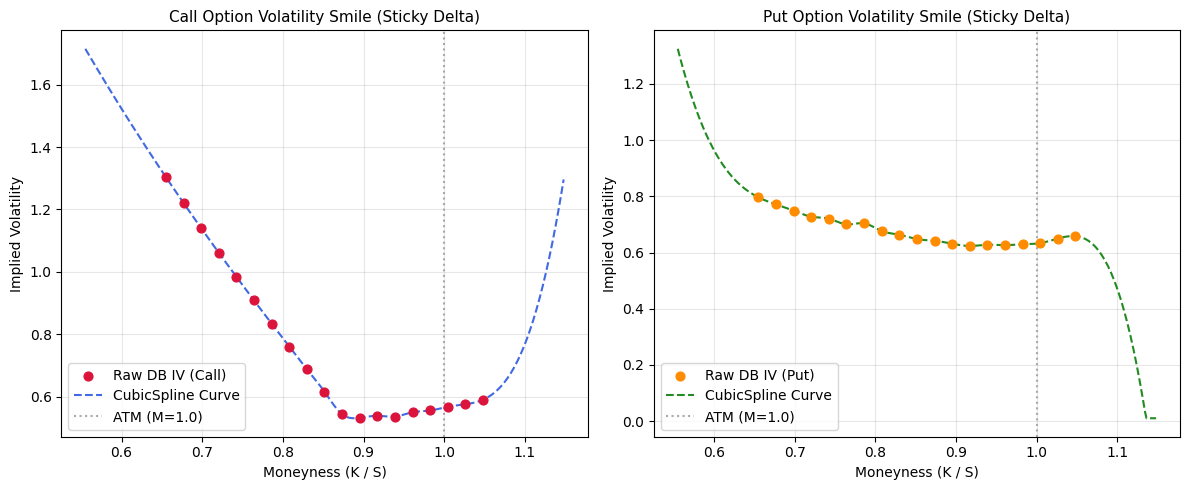

In [155]:
# 用于检查cubicspline的拟合效果
output_4of5(df_opt, Spot, cs_call, cs_put, df_target_temp)

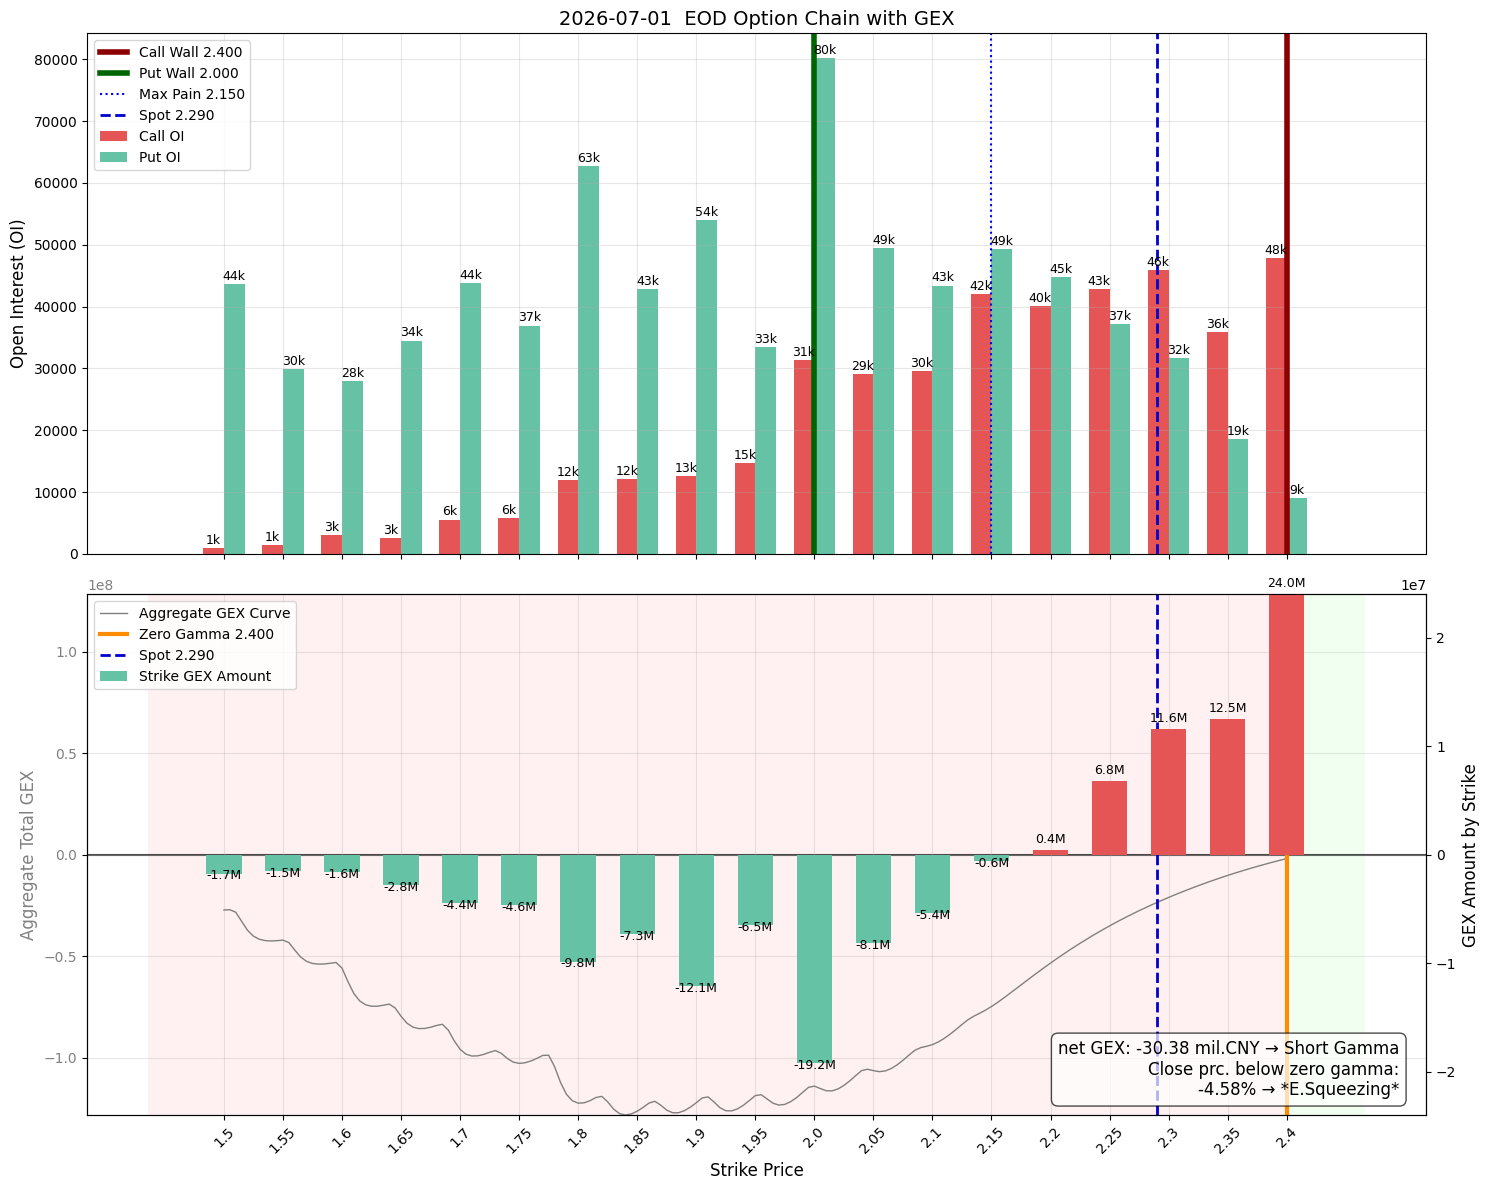

Net GEX: -30.38 mil.CNY -> Short Gamma
zero gamma: 2.400 
收盘价位于zero gamma 下方: -4.58% -> *放大器信号*


In [156]:
# 用于查看该日，期权链的gamma暴露值
output_5of5(df_tag, gex_table, metrics_df)

In [157]:
metrics_df = output_6of5(df_tag, Spot, rf_dynamic, DTE_n, metrics_df)

理论远期价格 F: 2.230
最贴近远期价格的行权价 K_zero: 2.200


In [158]:
display(metrics_df)
# 保存指标数据到临时文件，供循环程序读取
metrics_df.to_csv("tmp_metrics_temp.csv", index=False)

,date,spot,put_wall,call_wall,max_pain,net_gex(M),zero-gamma,hv30,hv60,hv90,PRR(cny),25Delta_Skew,vola_ratio,atm_iv,VIX_estimate
0,2026-07-01,2.29,2.0,2.4,2.15,-30.38,2.4,52.612274,45.55336,42.140419,-0.35,-0.0414,0.9344,56.73,56.464
